In [4]:
# import sys, subprocess
# print("Using interpreter:", sys.executable)
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "sdv"])

Using interpreter: /users/PDS0345/rxa615/.conda/envs/alphagenome-env/bin/python
  Using cached sdv-1.25.0-py3-none-any.whl.metadata (14 kB)
  Using cached boto3-1.40.5-py3-none-any.whl.metadata (6.7 kB)
  Using cached botocore-1.40.5-py3-none-any.whl.metadata (5.7 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached copulas-0.12.3-py3-none-any.whl.metadata (9.5 kB)
  Using cached ctgan-0.11.0-py3-none-any.whl.metadata (10 kB)
  Using cached deepecho-0.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached rdt-1.17.1-py3-none-any.whl.metadata (10 kB)
  Using cached sdmetrics-0.22.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached jmespath-1.0.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached s3transfer-0.13.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached plotly-6.2.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.0.1-py3-none-any.whl.metadata (11 kB)
  Using cached faker-3

0

In [7]:
import pandas as pd
from sdv.metadata import Metadata          
from sdv.single_table import TVAESynthesizer

In [8]:
df = pd.read_csv("bn_synthetic_generation_df.csv", low_memory=False)

In [29]:
df.shape

(439221, 265)

In [18]:
metadata = Metadata.detect_from_dataframe(df)

synth = TVAESynthesizer(
    metadata,
    epochs=100,       
    batch_size=5000
)

synth.fit(df)

/users/PDS0345/rxa615/.conda/envs/alphagenome-env/lib/python3.11/site-packages/sdv/single_table/base.py:133: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [19]:
synth.save("tvae_synth.pkl")
print("Model saved to tvae_synth.pkl")

Model saved to tvae_synth.pkl


In [20]:
from sdv.single_table import TVAESynthesizer
loaded_synth = TVAESynthesizer.load("tvae_synth.pkl")

/users/PDS0345/rxa615/.conda/envs/alphagenome-env/lib/python3.11/site-packages/sdv/_utils.py:500: FutureWarning: The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.
  warnings.warn(


In [33]:
# === Generate synthetic samples ===
synthetic_df = loaded_synth.sample(num_rows=5000)
synthetic_df.head()

,sex,ethnicity_name,ref_age,D10-D36 Benign neoplasms,A30-A49 Other bacterial diseases,A00-A09 Intestinal infectious diseases,M80-M85 Disorders of bone density and structure,K65-K67 Diseases of peritoneum,"R70-R79 Abnormal findings on examination of blood, without diagnosis",D50-D53 Nutritional anaemias,...,V98-V99 Other and unspecified transport accidents,Y90-Y98 Supplementary factors related to causes of morbidity and mortality classified elsewhere,U82-U85 Resistance to antimicrobial and antineoplastic drugs,P35-P39 Infections specific to the perinatal period,Y35-Y36 Legal intervention and operations of war,T33-T35 Frostbite,"P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery",P05-P08 Disorders related to length of gestation and fetal growth,R95-R99 Ill-defined and unknown causes of mortality,P50-P61 Haemorrhagic and haematological disorders of fetus and newborn
0,1,British,66.145484,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,British,73.856070,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,British,63.636007,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,British,73.022311,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,British,47.845518,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [89]:
df.shape

(439221, 265)

In [94]:
from sdv.single_table import CTGANSynthesizer

metadata = Metadata.detect_from_dataframe(df)

# Instantiate CTGAN
ctgan = CTGANSynthesizer(
    metadata,
    epochs=100,        # adjust epochs as needed
    batch_size=5000,
    verbose=True
)

# Train CTGAN on full data (or sample)
ctgan.fit(df)

# Save CTGAN model
ctgan.save("ctgan_synth.pkl")

/users/PDS0345/rxa615/.conda/envs/alphagenome-env/lib/python3.11/site-packages/sdv/single_table/base.py:133: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-4.39) | Discrim. (0.77): 100%|██████████| 100/100 [36:58<00:00, 22.19s/it] 


In [97]:
loss= ctgan.get_loss_values()

In [98]:
loss

,Epoch,Generator Loss,Discriminator Loss
0,0,-16.209707,-0.668041
1,1,-17.820761,-0.605488
2,2,-15.055266,0.758419
3,3,-19.123171,0.193344
4,4,-20.053230,0.481527
...,...,...,...
95,95,-2.231857,0.720661
96,96,-3.571256,-0.413294
97,97,-2.917052,-0.012859
98,98,-4.984606,0.147582


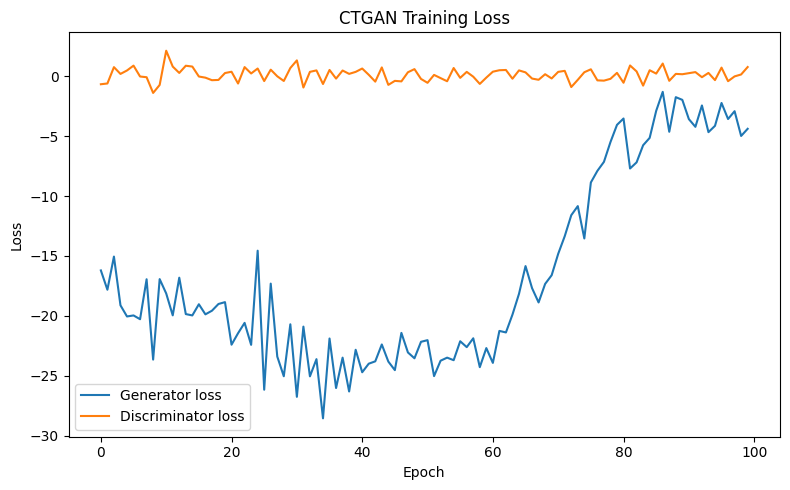

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

loss.columns = [c.strip().lower().replace(" ", "_") for c in loss.columns]

# Keep only needed columns and sort by epoch
loss = loss.rename(columns={
    "epoch": "epoch",
    "generator_loss": "gen_loss",
    "discriminator_loss": "disc_loss"
})[["epoch", "gen_loss", "disc_loss"]].sort_values("epoch").reset_index(drop=True)

# Save a clean copy
loss.to_csv("ctgan_losses.csv", index=False)

# === Plot ===
plt.figure(figsize=(8,5))
plt.plot(loss["epoch"], loss["gen_loss"], label="Generator loss")
plt.plot(loss["epoch"], loss["disc_loss"], label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CTGAN Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("ctgan_loss_curve.png", dpi=200)
plt.show()

In [103]:
loaded_ctgan = CTGANSynthesizer.load("ctgan_synth.pkl")

/users/PDS0345/rxa615/.conda/envs/alphagenome-env/lib/python3.11/site-packages/sdv/_utils.py:500: FutureWarning:

The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.



In [119]:
# === Generate synthetic samples ===
synthetic_df = loaded_ctgan.sample(num_rows=50000)
synthetic_df.head()

,sex,ethnicity_name,ref_age,D10-D36 Benign neoplasms,A30-A49 Other bacterial diseases,A00-A09 Intestinal infectious diseases,M80-M85 Disorders of bone density and structure,K65-K67 Diseases of peritoneum,"R70-R79 Abnormal findings on examination of blood, without diagnosis",D50-D53 Nutritional anaemias,...,V98-V99 Other and unspecified transport accidents,Y90-Y98 Supplementary factors related to causes of morbidity and mortality classified elsewhere,U82-U85 Resistance to antimicrobial and antineoplastic drugs,P35-P39 Infections specific to the perinatal period,Y35-Y36 Legal intervention and operations of war,T33-T35 Frostbite,"P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery",P05-P08 Disorders related to length of gestation and fetal growth,R95-R99 Ill-defined and unknown causes of mortality,P50-P61 Haemorrhagic and haematological disorders of fetus and newborn
0,1,British,65.055524,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,Irish,59.004463,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,Irish,70.226316,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,British,56.836572,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,British,49.915555,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [120]:
# Identify binary columns
binary_cols = [col for col in synthetic_df.columns if col not in exclude_cols]

# Convert to numeric (forcing errors to NaN, then fill with 0)
df[binary_cols] = df[binary_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
synthetic_df[binary_cols] = synthetic_df[binary_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# Count number of 1's per row
df["num_diseases"] = df[binary_cols].sum(axis=1)
synthetic_df["num_diseases"] = synthetic_df[binary_cols].sum(axis=1)

real_counts = df["num_diseases"].value_counts().sort_index()
synthetic_counts = synthetic_df["num_diseases"].value_counts().sort_index()


/tmp/slurmtmp.36924182/ipykernel_1667676/1032521252.py:10: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



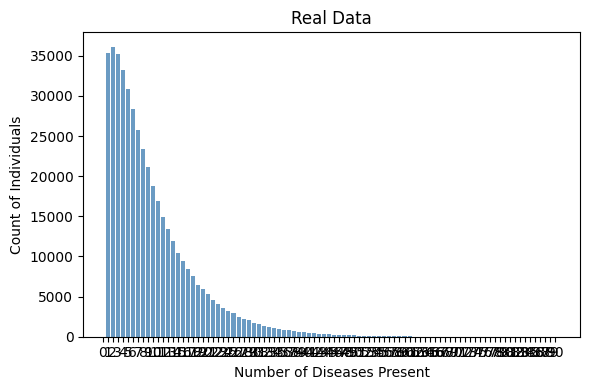

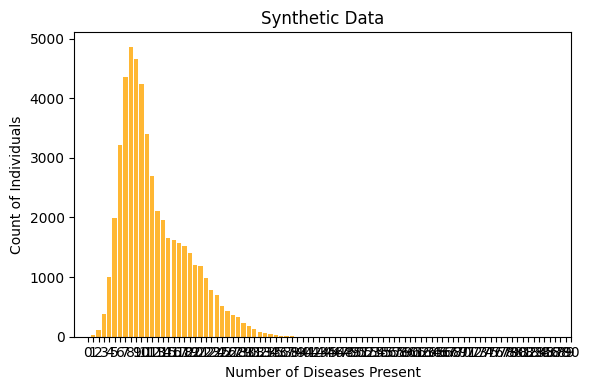

In [121]:
# Define bin positions (0 up to max disease count in either dataset)
bins = range(0, max(real_counts.index.max(), synthetic_counts.index.max()) + 1)

# Real data
plt.figure(figsize=(6,4))
plt.bar(real_counts.index, real_counts.values, color='steelblue', alpha=0.8)
plt.xticks(bins)  # set bin ticks
plt.title("Real Data")
plt.xlabel("Number of Diseases Present")
plt.ylabel("Count of Individuals")
plt.tight_layout()
plt.show()

# Synthetic data
plt.figure(figsize=(6,4))
plt.bar(synthetic_counts.index, synthetic_counts.values, color='orange', alpha=0.8)
plt.xticks(bins)  # set bin ticks
plt.title("Synthetic Data")
plt.xlabel("Number of Diseases Present")
plt.ylabel("Count of Individuals")
plt.tight_layout()
plt.show()

In [124]:
synthetic_df.shape

(50000, 266)

In [125]:
# Columns to exclude from proportion calculation
exclude_cols = ["sex", "ref_age", "ethnicity_name"]

# Get binary columns
binary_cols = [col for col in synthetic_df.columns if col not in exclude_cols]

# Calculate proportion of 1's for each column
original_proportions = df[binary_cols].mean()
synthetic_proportions = synthetic_df[binary_cols].mean()

# Combine into a DataFrame for comparison
comparison_df = pd.DataFrame({
    "diagnosis_code": binary_cols,
    "original_proportion": original_proportions.values,
    "synthetic_proportion": synthetic_proportions.values
})

# Optional: save for inspection
comparison_df.to_csv("ctgan_50K_comparison_df_proportions.csv", index=False)


In [63]:
metadata

{
    "tables": {
        "table": {
            "columns": {
                "sex": {
                    "sdtype": "categorical"
                },
                "ethnicity_name": {
                    "sdtype": "categorical"
                },
                "ref_age": {
                    "sdtype": "numerical"
                },
                "D10-D36 Benign neoplasms": {
                    "sdtype": "categorical"
                },
                "A30-A49 Other bacterial diseases": {
                    "sdtype": "categorical"
                },
                "A00-A09 Intestinal infectious diseases": {
                    "sdtype": "categorical"
                },
                "M80-M85 Disorders of bone density and structure": {
                    "sdtype": "categorical"
                },
                "K65-K67 Diseases of peritoneum": {
                    "sdtype": "categorical"
                },
                "R70-R79 Abnormal findings on examination of bloo

In [128]:
metadata

{
    "tables": {
        "table": {
            "columns": {
                "sex": {
                    "sdtype": "categorical"
                },
                "ethnicity_name": {
                    "sdtype": "categorical"
                },
                "ref_age": {
                    "sdtype": "numerical"
                },
                "D10-D36 Benign neoplasms": {
                    "sdtype": "categorical"
                },
                "A30-A49 Other bacterial diseases": {
                    "sdtype": "categorical"
                },
                "A00-A09 Intestinal infectious diseases": {
                    "sdtype": "categorical"
                },
                "M80-M85 Disorders of bone density and structure": {
                    "sdtype": "categorical"
                },
                "K65-K67 Diseases of peritoneum": {
                    "sdtype": "categorical"
                },
                "R70-R79 Abnormal findings on examination of bloo

In [130]:
synthetic_df.shape

(50000, 266)

In [133]:
synthetic_df.columns

Index(['sex', 'ethnicity_name', 'ref_age', 'D10-D36 Benign neoplasms',
       'A30-A49 Other bacterial diseases',
       'A00-A09 Intestinal infectious diseases',
       'M80-M85 Disorders of bone density and structure',
       'K65-K67 Diseases of peritoneum',
       'R70-R79 Abnormal findings on examination of blood, without diagnosis',
       'D50-D53 Nutritional anaemias',
       ...
       'Y90-Y98 Supplementary factors related to causes of morbidity and mortality classified elsewhere',
       'U82-U85 Resistance to antimicrobial and antineoplastic drugs',
       'P35-P39 Infections specific to the perinatal period',
       'Y35-Y36 Legal intervention and operations of war', 'T33-T35 Frostbite',
       'P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery',
       'P05-P08 Disorders related to length of gestation and fetal growth',
       'R95-R99 Ill-defined and unknown causes of mortality',
       'P50-P61 Haemorrhagic and

In [131]:
df.shape

(439221, 266)

In [132]:
df.columns

Index(['sex', 'ethnicity_name', 'ref_age', 'D10-D36 Benign neoplasms',
       'A30-A49 Other bacterial diseases',
       'A00-A09 Intestinal infectious diseases',
       'M80-M85 Disorders of bone density and structure',
       'K65-K67 Diseases of peritoneum',
       'R70-R79 Abnormal findings on examination of blood, without diagnosis',
       'D50-D53 Nutritional anaemias',
       ...
       'Y90-Y98 Supplementary factors related to causes of morbidity and mortality classified elsewhere',
       'U82-U85 Resistance to antimicrobial and antineoplastic drugs',
       'P35-P39 Infections specific to the perinatal period',
       'Y35-Y36 Legal intervention and operations of war', 'T33-T35 Frostbite',
       'P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery',
       'P05-P08 Disorders related to length of gestation and fetal growth',
       'R95-R99 Ill-defined and unknown causes of mortality',
       'P50-P61 Haemorrhagic and

In [140]:
from sdv.evaluation.single_table import evaluate_quality
quality_report = evaluate_quality(
    df,
    synthetic_df,
    metadata)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 265/265 [00:11<00:00, 22.27it/s]|
Column Shapes Score: 96.69%

(2/2) Evaluating Column Pair Trends: |██████████| 34980/34980 [09:07<00:00, 63.92it/s]| 
Column Pair Trends Score: 93.99%

Overall Score (Average): 95.34%



In [141]:
quality_report.get_score()


np.float64(0.9533987324449356)

In [142]:
col_shape_details = quality_report.get_details(property_name="Column Shapes")

In [143]:
col_shape_details

,Column,Metric,Score
0,sex,TVComplement,0.776076
1,ethnicity_name,TVComplement,0.875543
2,ref_age,KSComplement,0.927840
3,D10-D36 Benign neoplasms,TVComplement,0.919675
4,A30-A49 Other bacterial diseases,TVComplement,0.997995
...,...,...,...
259,T33-T35 Frostbite,TVComplement,0.999360
260,P00-P04 Fetus and newborn affected by maternal...,TVComplement,0.999327
261,P05-P08 Disorders related to length of gestati...,TVComplement,0.999529
262,R95-R99 Ill-defined and unknown causes of mort...,TVComplement,0.999343


In [144]:
# === Column-pair relationship match details ===
pair_trend_details = quality_report.get_details(property_name="Column Pair Trends")
pair_trend_details

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation
0,sex,ethnicity_name,ContingencySimilarity,0.75470,NaN,NaN
1,sex,ref_age,ContingencySimilarity,0.76222,NaN,NaN
2,sex,D10-D36 Benign neoplasms,ContingencySimilarity,0.77524,NaN,NaN
3,sex,A30-A49 Other bacterial diseases,ContingencySimilarity,0.77336,NaN,NaN
4,sex,A00-A09 Intestinal infectious diseases,ContingencySimilarity,0.76658,NaN,NaN
...,...,...,...,...,...,...
34711,P00-P04 Fetus and newborn affected by maternal...,R95-R99 Ill-defined and unknown causes of mort...,ContingencySimilarity,0.99868,NaN,NaN
34712,P00-P04 Fetus and newborn affected by maternal...,P50-P61 Haemorrhagic and haematological disord...,ContingencySimilarity,0.99832,NaN,NaN
34713,P05-P08 Disorders related to length of gestati...,R95-R99 Ill-defined and unknown causes of mort...,ContingencySimilarity,0.99886,NaN,NaN
34714,P05-P08 Disorders related to length of gestati...,P50-P61 Haemorrhagic and haematological disord...,ContingencySimilarity,0.99854,NaN,NaN


In [147]:
low_pairs = pair_trend_details[pair_trend_details['Score'] < 0.6]
low_pairs

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation
298,ethnicity_name,I10-I15 Hypertensive diseases,ContingencySimilarity,0.59874,NaN,NaN
559,ref_age,I10-I15 Hypertensive diseases,ContingencySimilarity,0.59138,NaN,NaN
1336,A00-A09 Intestinal infectious diseases,I10-I15 Hypertensive diseases,ContingencySimilarity,0.59536,NaN,NaN
1593,M80-M85 Disorders of bone density and structure,I10-I15 Hypertensive diseases,ContingencySimilarity,0.59722,NaN,NaN
2611,"B95-B98 Bacterial, viral and other infectious ...",I10-I15 Hypertensive diseases,ContingencySimilarity,0.59216,NaN,NaN
3114,"G50-G59 Nerve, nerve root and plexus disorders",I10-I15 Hypertensive diseases,ContingencySimilarity,0.59054,NaN,NaN
3613,"I80-I89 Diseases of veins, lymphatic vessels a...",I10-I15 Hypertensive diseases,ContingencySimilarity,0.58370,NaN,NaN
4354,C43-C44 Melanoma and other malignant neoplasms...,I10-I15 Hypertensive diseases,ContingencySimilarity,0.59886,NaN,NaN
4599,E00-E07 Disorders of thyroid gland,I10-I15 Hypertensive diseases,ContingencySimilarity,0.55284,NaN,NaN
4612,E00-E07 Disorders of thyroid gland,"I70-I79 Diseases of arteries, arterioles and c...",ContingencySimilarity,0.53222,NaN,NaN


In [148]:
# === Generate synthetic samples ===
test_synthetic_df = loaded_ctgan.sample(num_rows=10000)
test_synthetic_df.head()

,sex,ethnicity_name,ref_age,D10-D36 Benign neoplasms,A30-A49 Other bacterial diseases,A00-A09 Intestinal infectious diseases,M80-M85 Disorders of bone density and structure,K65-K67 Diseases of peritoneum,"R70-R79 Abnormal findings on examination of blood, without diagnosis",D50-D53 Nutritional anaemias,...,V98-V99 Other and unspecified transport accidents,Y90-Y98 Supplementary factors related to causes of morbidity and mortality classified elsewhere,U82-U85 Resistance to antimicrobial and antineoplastic drugs,P35-P39 Infections specific to the perinatal period,Y35-Y36 Legal intervention and operations of war,T33-T35 Frostbite,"P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery",P05-P08 Disorders related to length of gestation and fetal growth,R95-R99 Ill-defined and unknown causes of mortality,P50-P61 Haemorrhagic and haematological disorders of fetus and newborn
0,1,British,67.440957,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,British,68.219388,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,British,65.636213,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,British,84.408165,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,Irish,52.322946,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Save test synthetic dataset
test_synthetic_df.to_csv("test_10K_llm_synthetic_df.csv", index=False)

# Save train synthetic dataset
synthetic_df.to_csv("train_50K_llm_synthetic_df.csv", index=False)


In [149]:
import pandas as pd

# Columns to exclude from the diagnosis list
exclude_cols = ["sex", "ref_age", "ethnicity_name"]

# Identify diagnosis columns (all binary disease columns)
disease_cols = [col for col in synthetic_df.columns if col not in exclude_cols]

def collapse_diagnoses(df):
    return pd.DataFrame({
        "sex": df["sex"],
        "ref_age": df["ref_age"],
        "diagnosis": df[disease_cols].apply(
            lambda row: ", ".join([col for col in disease_cols if row[col] == 1]),
            axis=1
        )
    })

# Transform both datasets
train_diag_df = collapse_diagnoses(synthetic_df)
test_diag_df = collapse_diagnoses(test_synthetic_df)

In [150]:
test_diag_df.head()

,sex,ref_age,diagnosis
0,1,67.440957,"E00-E07 Disorders of thyroid gland, N80-N98 No..."
1,0,68.219388,"D10-D36 Benign neoplasms, H10-H13 Disorders of..."
2,1,65.636213,"I10-I15 Hypertensive diseases, I70-I79 Disease..."
3,1,84.408165,"I10-I15 Hypertensive diseases, K40-K46 Hernia,..."
4,1,52.322946,R70-R79 Abnormal findings on examination of bl...


In [151]:
train_diag_df.head()

,sex,ref_age,diagnosis
0,1,65.055524,"K55-K64 Other diseases of intestines, M20-M25 ..."
1,1,59.004463,"H25-H28 Disorders of lens, E00-E07 Disorders o..."
2,1,70.226316,"E00-E07 Disorders of thyroid gland, I10-I15 Hy..."
3,1,56.836572,"K65-K67 Diseases of peritoneum, K20-K31 Diseas..."
4,0,49.915555,"H25-H28 Disorders of lens, K55-K64 Other disea..."


In [152]:
train_diag_df.to_csv("train_50K_llm_synthetic_df.csv", index=False)
test_diag_df.to_csv("test_10K_llm_synthetic_df.csv", index=False)

In [154]:
synthetic_df.to_csv("train_50K_llm_synthetic_df_wide.csv", index=False)
test_synthetic_df.to_csv("test_10K_llm_synthetic_df_wide.csv", index=False)